# Credit Risk Classification - Model Training and Evaluation

**BITS Pilani WILP - M.Tech (AIML/DSE) - Machine Learning Assignment 2**

This notebook builds an end-to-end supervised learning workflow on the
**Statlog (German Credit Data)** dataset from the UCI Machine Learning Repository.

Workflow implemented in this notebook:

1. Load the raw dataset and decode the UCI attribute codes into readable labels
2. Exploratory Data Analysis (EDA)
3. Missing value handling
4. Categorical encoding and feature scaling (inside leak-proof pipelines)
5. Stratified train / test split
6. Training of five classifiers with cross-validated hyper-parameter search
7. Evaluation on the held-out test set (Accuracy, AUC, Precision, Recall, F1, MCC)
8. Comparison table, plots and model persistence (`.pkl`) for the Streamlit app

In [1]:
"""Imports, global configuration and reproducibility settings."""

from __future__ import annotations

import json
import warnings
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

# Single seed reused everywhere so that every result in this notebook is reproducible.
RANDOM_STATE = 42
TEST_SIZE = 0.25
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Resolve the project root whether the notebook is run from ./ or ./notebooks
ROOT = Path.cwd()
if not (ROOT / "data" / "german.data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
for _directory in (MODEL_DIR, REPORT_DIR, FIGURE_DIR):
    _directory.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"pandas       : {pd.__version__}")

Project root : C:\Users\1000302425\Desktop\AIML\ML\A2\ml-assignment-2
scikit-learn : 1.9.0
pandas       : 3.0.5


## 1. Dataset loading

**Source:** UCI Machine Learning Repository - *Statlog (German Credit Data)*
(https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

The raw file `german.data` is space separated, has no header row and stores every
qualitative attribute as an opaque code (`A11`, `A34`, ...). The dictionaries below
translate those codes into business-readable categories, which makes the EDA, the
saved `test_data.csv` and the Streamlit UI far easier to interpret.

* 20 predictor attributes (13 qualitative + 7 numerical) - requirement: >= 12
* 1,000 loan applicants - requirement: >= 500
* Binary target: `credit_risk` -> `Good` / `Bad`

In [2]:
"""Load the raw UCI file and decode the attribute codes into readable labels."""

COLUMN_NAMES = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate_pct_income",
    "personal_status_sex",
    "other_debtors",
    "residence_since_years",
    "property_type",
    "age_years",
    "other_installment_plans",
    "housing",
    "existing_credits_at_bank",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "credit_risk",
]

# Code -> human readable label, exactly as documented in the UCI `german.doc` file.
CODE_MAPS: dict[str, dict[str, str]] = {
    "checking_account_status": {
        "A11": "< 0 DM",
        "A12": "0 - 200 DM",
        "A13": ">= 200 DM",
        "A14": "no checking account",
    },
    "credit_history": {
        "A30": "no credit taken / all paid",
        "A31": "all paid at this bank",
        "A32": "existing credits paid duly",
        "A33": "delay in past payments",
        "A34": "critical account / other credits",
    },
    "purpose": {
        "A40": "car (new)",
        "A41": "car (used)",
        "A42": "furniture / equipment",
        "A43": "radio / television",
        "A44": "domestic appliances",
        "A45": "repairs",
        "A46": "education",
        "A47": "vacation",
        "A48": "retraining",
        "A49": "business",
        "A410": "others",
    },
    "savings_account": {
        "A61": "< 100 DM",
        "A62": "100 - 500 DM",
        "A63": "500 - 1000 DM",
        "A64": ">= 1000 DM",
        "A65": "unknown / no savings",
    },
    "employment_since": {
        "A71": "unemployed",
        "A72": "< 1 year",
        "A73": "1 - 4 years",
        "A74": "4 - 7 years",
        "A75": ">= 7 years",
    },
    "personal_status_sex": {
        "A91": "male : divorced / separated",
        "A92": "female : divorced / separated / married",
        "A93": "male : single",
        "A94": "male : married / widowed",
        "A95": "female : single",
    },
    "other_debtors": {
        "A101": "none",
        "A102": "co-applicant",
        "A103": "guarantor",
    },
    "property_type": {
        "A121": "real estate",
        "A122": "building society savings / life insurance",
        "A123": "car or other",
        "A124": "unknown / no property",
    },
    "other_installment_plans": {
        "A141": "bank",
        "A142": "stores",
        "A143": "none",
    },
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unemployed / unskilled non-resident",
        "A172": "unskilled resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified",
    },
    "telephone": {"A191": "none", "A192": "registered"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

# UCI encodes 1 = good credit risk, 2 = bad credit risk.
TARGET_MAP = {1: "Good", 2: "Bad"}


def load_german_credit(raw_path: Path) -> pd.DataFrame:
    """Read `german.data` and return a decoded, analysis-ready DataFrame.

    Parameters
    ----------
    raw_path : Path
        Location of the raw space-separated UCI file.

    Returns
    -------
    pandas.DataFrame
        Data frame with readable column names and decoded categorical labels.
    """
    if not raw_path.exists():
        raise FileNotFoundError(
            f"Raw dataset not found at {raw_path}. "
            "Download it from https://archive.ics.uci.edu/dataset/144/"
        )

    frame = pd.read_csv(raw_path, sep=r"\s+", header=None, names=COLUMN_NAMES)
    for column, mapping in CODE_MAPS.items():
        frame[column] = frame[column].map(mapping)
    frame["credit_risk"] = frame["credit_risk"].map(TARGET_MAP)
    return frame


df = load_german_credit(DATA_DIR / "german.data")

# Persist the decoded dataset so the repository is self-contained and auditable.
CLEAN_CSV = DATA_DIR / "german_credit_clean.csv"
df.to_csv(CLEAN_CSV, index=False)

print(f"Rows x Columns : {df.shape[0]} x {df.shape[1]}")
print(f"Predictors     : {df.shape[1] - 1}")
df.head()

Rows x Columns : 1000 x 21


Predictors     : 20


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property_type,age_years,other_installment_plans,housing,existing_credits_at_bank,job,dependents,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits,radio / television,1169,unknown / no savings,>= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,registered,yes,Good
1,0 - 200 DM,48,existing credits paid duly,radio / television,5951,< 100 DM,1 - 4 years,2,female : divorced / separated / married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,Bad
2,no checking account,12,critical account / other credits,education,2096,< 100 DM,4 - 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,Good
3,< 0 DM,42,existing credits paid duly,furniture / equipment,7882,< 100 DM,4 - 7 years,2,male : single,guarantor,...,building society savings / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,Good
4,< 0 DM,24,delay in past payments,car (new),4870,< 100 DM,1 - 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,Bad


## 2. Exploratory Data Analysis (EDA)

In [3]:
"""Structural overview: dtypes, non-null counts and memory footprint."""

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   checking_account_status      1000 non-null   str  
 1   duration_months              1000 non-null   int64
 2   credit_history               1000 non-null   str  
 3   purpose                      1000 non-null   str  
 4   credit_amount                1000 non-null   int64
 5   savings_account              1000 non-null   str  
 6   employment_since             1000 non-null   str  
 7   installment_rate_pct_income  1000 non-null   int64
 8   personal_status_sex          1000 non-null   str  
 9   other_debtors                1000 non-null   str  
 10  residence_since_years        1000 non-null   int64
 11  property_type                1000 non-null   str  
 12  age_years                    1000 non-null   int64
 13  other_installment_plans      1000 non-null   str  
 14  hous

In [4]:
"""Missing value audit - performed before any modelling decision is taken."""

missing = df.isna().sum()
missing_report = pd.DataFrame(
    {
        "missing_count": missing,
        "missing_pct": (missing / len(df) * 100).round(2),
    }
).sort_values("missing_count", ascending=False)

print(f"Total missing cells : {int(missing.sum())}")
print(f"Duplicate rows      : {int(df.duplicated().sum())}")
missing_report.head(10)

Total missing cells : 0
Duplicate rows      : 0


,missing_count,missing_pct
checking_account_status,0,0.0
duration_months,0,0.0
credit_history,0,0.0
purpose,0,0.0
credit_amount,0,0.0
savings_account,0,0.0
employment_since,0,0.0
installment_rate_pct_income,0,0.0
personal_status_sex,0,0.0
other_debtors,0,0.0


The Statlog German Credit data is complete - there are **no missing cells and no
duplicate records**. Median / most-frequent imputers are nevertheless kept inside the
modelling pipelines so that the deployed Streamlit application degrades gracefully if
a user uploads a file that contains blank fields.

             count  percent
credit_risk                
Good           700     70.0
Bad            300     30.0

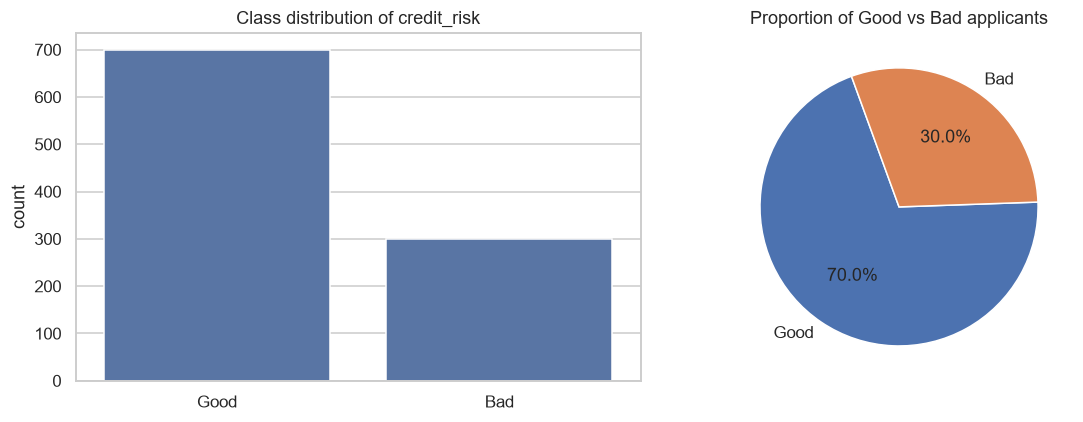

In [5]:
"""Target distribution - class balance drives the choice of evaluation metrics."""

target_counts = df["credit_risk"].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)
print(pd.concat([target_counts, target_pct], axis=1, keys=["count", "percent"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="credit_risk", data=df, order=["Good", "Bad"], ax=axes[0])
axes[0].set_title("Class distribution of credit_risk")
axes[0].set_xlabel("")
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=110,
    colors=["#4c72b0", "#dd8452"],
)
axes[1].set_title("Proportion of Good vs Bad applicants")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_distribution.png", bbox_inches="tight")
plt.show()

In [6]:
"""Descriptive statistics of the seven numerical attributes."""

numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    column
    for column in df.columns
    if column not in numeric_features and column != "credit_risk"
]

print(f"Numerical attributes   ({len(numeric_features)}): {numeric_features}")
print(f"Categorical attributes ({len(categorical_features)}): {categorical_features}")
df[numeric_features].describe().T.round(2)

Numerical attributes   (7): ['duration_months', 'credit_amount', 'installment_rate_pct_income', 'residence_since_years', 'age_years', 'existing_credits_at_bank', 'dependents']
Categorical attributes (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property_type', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.90,12.06,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.26,2822.74,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate_pct_income,1000.0,2.97,1.12,1.0,2.0,3.0,4.00,4.0
residence_since_years,1000.0,2.84,1.10,1.0,2.0,3.0,4.00,4.0
age_years,1000.0,35.55,11.38,19.0,27.0,33.0,42.00,75.0
existing_credits_at_bank,1000.0,1.41,0.58,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.16,0.36,1.0,1.0,1.0,1.00,2.0


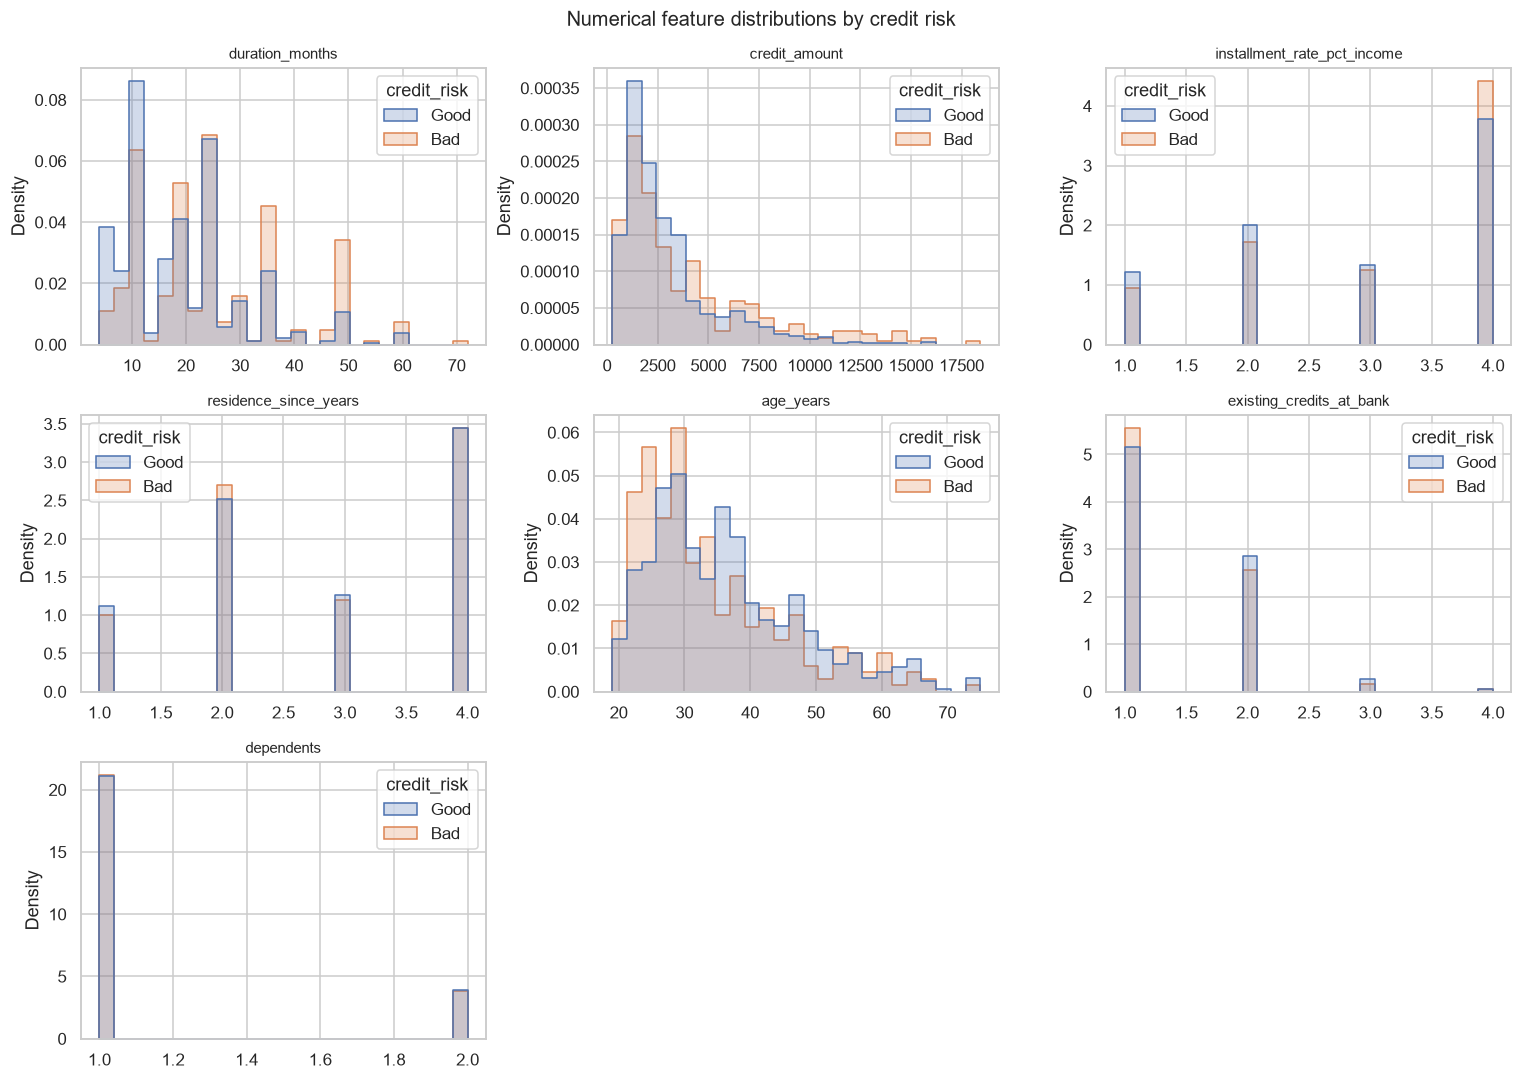

In [7]:
"""Distribution of the numerical attributes split by the target class."""

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for axis, feature in zip(axes.ravel(), numeric_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="credit_risk",
        hue_order=["Good", "Bad"],
        bins=25,
        element="step",
        stat="density",
        common_norm=False,
        ax=axis,
    )
    axis.set_title(feature, fontsize=10)
    axis.set_xlabel("")
for axis in axes.ravel()[len(numeric_features):]:
    axis.set_visible(False)
fig.suptitle("Numerical feature distributions by credit risk", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "numeric_distributions.png", bbox_inches="tight")
plt.show()

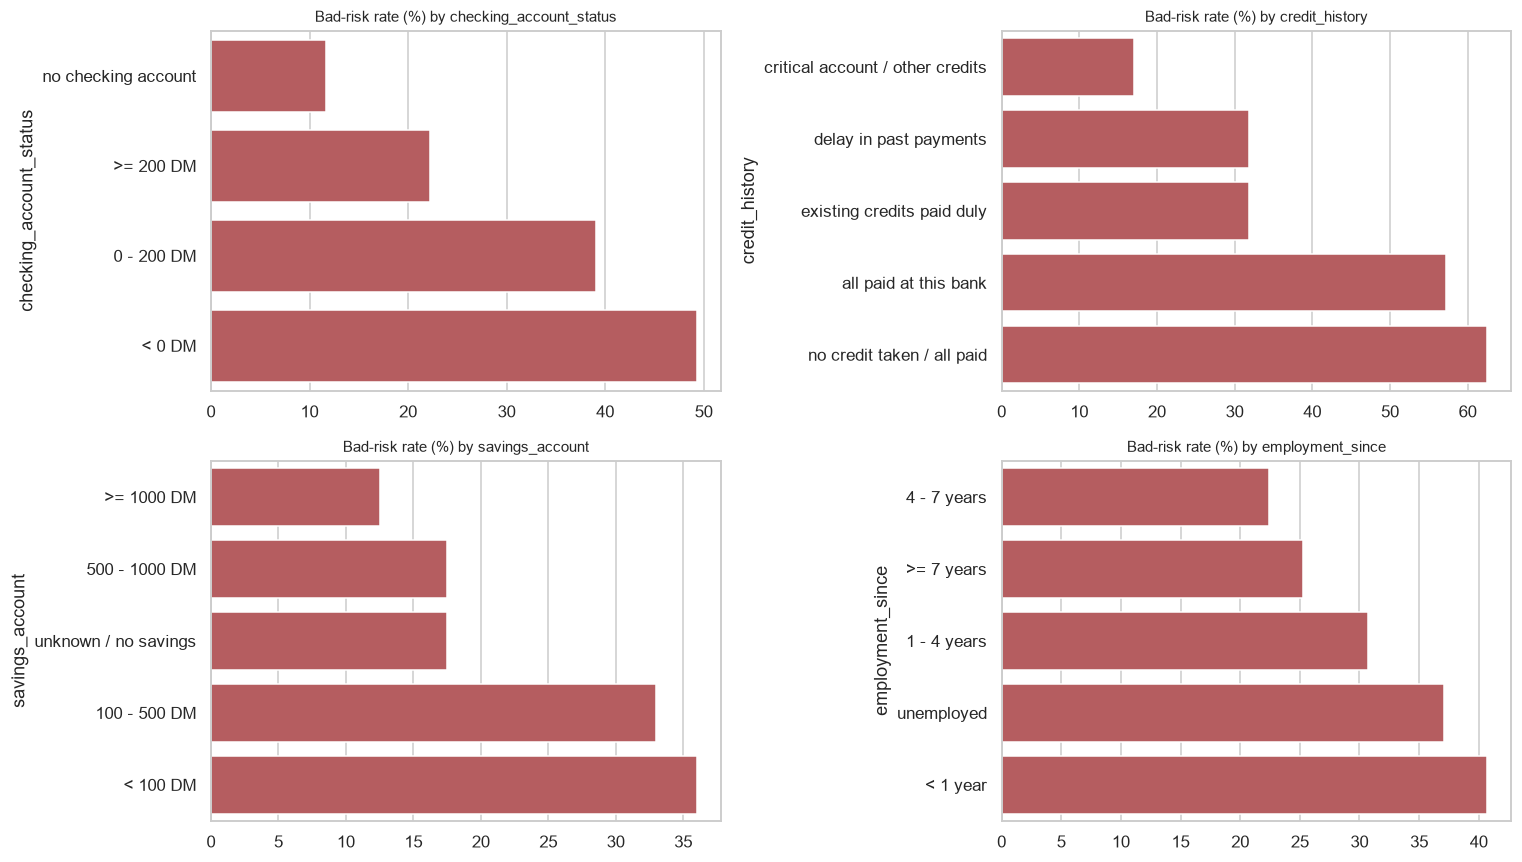

In [8]:
"""Default rate for the most informative qualitative attributes."""

key_categoricals = [
    "checking_account_status",
    "credit_history",
    "savings_account",
    "employment_since",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for axis, feature in zip(axes.ravel(), key_categoricals):
    share = (
        df.groupby(feature)["credit_risk"]
        .apply(lambda s: (s == "Bad").mean() * 100)
        .sort_values()
    )
    sns.barplot(x=share.values, y=share.index, ax=axis, color="#c44e52")
    axis.set_title(f"Bad-risk rate (%) by {feature}", fontsize=10)
    axis.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "categorical_bad_rate.png", bbox_inches="tight")
plt.show()

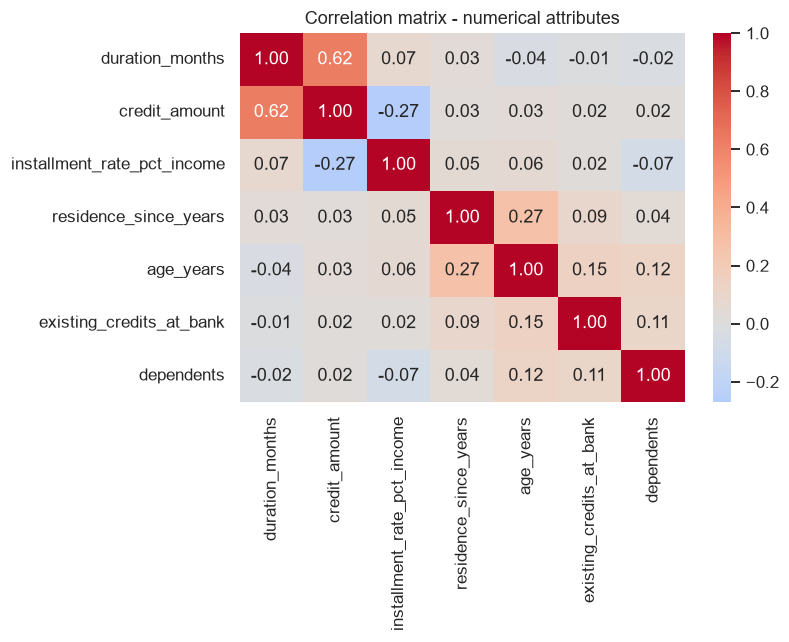

In [9]:
"""Correlation structure of the numerical block (multicollinearity check)."""

fig, axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axis,
)
axis.set_title("Correlation matrix - numerical attributes")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "correlation_matrix.png", bbox_inches="tight")
plt.show()

## 3. Preprocessing design

Every transformation is wrapped inside a `ColumnTransformer` that is itself the first
stage of each model `Pipeline`. Because the pipeline is fitted **only on the training
fold**, imputation statistics, one-hot vocabularies and scaling parameters can never
leak from the test set.

| Block | Steps |
|---|---|
| 7 numerical columns | median imputation -> `StandardScaler` |
| 13 categorical columns | most-frequent imputation -> `OneHotEncoder(handle_unknown="ignore")` |

`handle_unknown="ignore"` is essential for deployment: an uploaded CSV containing an
unseen category will not crash the application.

In [10]:
"""Factory that returns a fresh, unfitted preprocessing ColumnTransformer."""


def build_preprocessor(
    numeric_cols: list[str], categorical_cols: list[str]
) -> ColumnTransformer:
    """Create the shared preprocessing block used by every model pipeline."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# Quick sanity check of the expanded design-matrix width.
_probe = build_preprocessor(numeric_features, categorical_features)
_probe.fit(df.drop(columns="credit_risk"))
print(f"Features after one-hot encoding: {len(_probe.get_feature_names_out())}")

Features after one-hot encoding: 61


## 4. Train / test split

A **stratified 75 / 25 split** with `random_state=42` preserves the 70:30 class ratio
in both partitions. The positive class is defined as **`Bad` credit risk (label 1)**,
because the business cost of approving a defaulting applicant is the risk the bank
actually wants to detect (the UCI cost matrix weighs this error 5x higher than
rejecting a good applicant).

In [11]:
"""Stratified split and export of the held-out test set for the Streamlit app."""

POSITIVE_LABEL = "Bad"
TARGET = "credit_risk"

X = df.drop(columns=TARGET)
y_labels = df[TARGET]
y = (y_labels == POSITIVE_LABEL).astype(int)  # 1 = Bad risk, 0 = Good risk

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]} rows | Bad rate = {y_train.mean():.3f}")
print(f"Test set     : {X_test.shape[0]} rows | Bad rate = {y_test.mean():.3f}")

# The exported CSV keeps the original readable labels so that it can be inspected,
# uploaded to the Streamlit app and used to recompute every metric independently.
test_export = X_test.copy()
test_export[TARGET] = y_labels.loc[X_test.index]
test_export.to_csv(ROOT / "test_data.csv", index=False)
print(f"Saved -> {ROOT / 'test_data.csv'}  ({test_export.shape[0]} rows)")
test_export.head()

Training set : 750 rows | Bad rate = 0.300
Test set     : 250 rows | Bad rate = 0.300
Saved -> C:\Users\1000302425\Desktop\AIML\ML\A2\ml-assignment-2\test_data.csv  (250 rows)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property_type,age_years,other_installment_plans,housing,existing_credits_at_bank,job,dependents,telephone,foreign_worker,credit_risk
522,< 0 DM,48,no credit taken / all paid,furniture / equipment,7119,< 100 DM,1 - 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,Bad
681,no checking account,12,existing credits paid duly,radio / television,2279,unknown / no savings,1 - 4 years,4,male : single,none,...,unknown / no property,37,none,for free,1,skilled employee / official,1,registered,yes,Good
436,no checking account,6,existing credits paid duly,repairs,660,500 - 1000 DM,4 - 7 years,2,male : married / widowed,none,...,real estate,23,none,rent,1,unskilled resident,1,none,yes,Good
860,no checking account,24,critical account / other credits,car (used),5804,>= 1000 DM,1 - 4 years,4,male : single,none,...,real estate,27,none,own,2,skilled employee / official,1,none,yes,Good
455,no checking account,24,existing credits paid duly,car (used),2679,< 100 DM,< 1 year,4,female : divorced / separated / married,none,...,unknown / no property,29,none,own,1,management / self-employed / highly qualified,1,registered,yes,Good


## 5. Model training

Five classifiers are trained on the identical training partition. Each one is a
complete `Pipeline` (`preprocessing -> estimator`), so a single `.pkl` file is
sufficient to score raw, human-readable data inside the web application.

Hyper-parameters are selected with a **5-fold stratified `GridSearchCV`** optimised
for `roc_auc`, a threshold-independent criterion that is appropriate for an
imbalanced problem. `class_weight="balanced"` is enabled for the estimators that
support it (Logistic Regression, Decision Tree, Random Forest) to reflect the
asymmetric cost of a missed default; K-Nearest Neighbours and Gaussian Naive Bayes do
not expose that parameter, which is taken into account when the results are discussed.

In [12]:
"""Model zoo: estimator + hyper-parameter grid for every algorithm."""

MODEL_SPECS: dict[str, dict] = {
    "Logistic Regression": {
        "slug": "logistic_regression",
        "estimator": LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "grid": {
            "model__C": [0.05, 0.1, 0.5, 1.0, 5.0],
            "model__penalty": ["l1", "l2"],
        },
    },
    "Decision Tree": {
        "slug": "decision_tree",
        "estimator": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [3, 4, 5, 7, 10],
            "model__min_samples_leaf": [5, 10, 20],
        },
    },
    "KNN": {
        "slug": "knn",
        "estimator": KNeighborsClassifier(),
        "grid": {
            "model__n_neighbors": [5, 9, 15, 21, 31],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "Naive Bayes": {
        "slug": "naive_bayes",
        "estimator": GaussianNB(),
        "grid": {
            "model__var_smoothing": np.logspace(-9, -3, 7).tolist(),
        },
    },
    "Random Forest": {
        "slug": "random_forest",
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "grid": {
            "model__n_estimators": [300, 600],
            "model__max_depth": [None, 8, 14],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.4],
        },
    },
}

In [13]:
"""Fit every pipeline with cross-validated hyper-parameter search."""

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fitted_models: dict[str, Pipeline] = {}
search_summary: list[dict] = []

for name, spec in MODEL_SPECS.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_features, categorical_features)),
            ("model", spec["estimator"]),
        ]
    )
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["grid"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    fitted_models[name] = search.best_estimator_
    search_summary.append(
        {
            "ML Model": name,
            "CV AUC (mean)": round(float(search.best_score_), 4),
            "CV AUC (std)": round(
                float(search.cv_results_["std_test_score"][search.best_index_]), 4
            ),
            "Best Parameters": {
                key.replace("model__", ""): value
                for key, value in search.best_params_.items()
            },
        }
    )
    print(f"{name:<22} CV AUC = {search.best_score_:.4f} | {search.best_params_}")

cv_table = pd.DataFrame(search_summary)
cv_table.to_csv(REPORT_DIR / "cross_validation_results.csv", index=False)
cv_table

Logistic Regression    CV AUC = 0.7791 | {'model__C': 0.05, 'model__penalty': 'l2'}


Decision Tree          CV AUC = 0.7621 | {'model__criterion': 'gini', 'model__max_depth': 7, 'model__min_samples_leaf': 20}


KNN                    CV AUC = 0.7548 | {'model__n_neighbors': 31, 'model__p': 1, 'model__weights': 'distance'}


Naive Bayes            CV AUC = 0.7174 | {'model__var_smoothing': 0.001}


Random Forest          CV AUC = 0.7926 | {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 600}


,ML Model,CV AUC (mean),CV AUC (std),Best Parameters
0,Logistic Regression,0.7791,0.0210,"{'C': 0.05, 'penalty': 'l2'}"
1,Decision Tree,0.7621,0.0162,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
2,KNN,0.7548,0.0332,"{'n_neighbors': 31, 'p': 1, 'weights': 'distan..."
3,Naive Bayes,0.7174,0.0471,{'var_smoothing': 0.001}
4,Random Forest,0.7926,0.0139,"{'max_depth': None, 'max_features': 'sqrt', 'm..."


## 6. Evaluation on the held-out test set

All six mandated metrics are computed on the 250 unseen applicants. Precision, Recall
and F1 are reported for the positive class (`Bad` credit risk); AUC uses the predicted
probability of that class.

In [14]:
"""Metric helper and evaluation of every fitted pipeline."""


def evaluate_model(
    name: str, model: Pipeline, features: pd.DataFrame, truth: pd.Series
) -> dict:
    """Return the six mandated evaluation metrics for one fitted pipeline."""
    predictions = model.predict(features)
    probabilities = model.predict_proba(features)[:, 1]
    return {
        "ML Model": name,
        "Accuracy": round(accuracy_score(truth, predictions), 4),
        "AUC": round(roc_auc_score(truth, probabilities), 4),
        "Precision": round(precision_score(truth, predictions, zero_division=0), 4),
        "Recall": round(recall_score(truth, predictions, zero_division=0), 4),
        "F1": round(f1_score(truth, predictions, zero_division=0), 4),
        "MCC": round(matthews_corrcoef(truth, predictions), 4),
    }


results = pd.DataFrame(
    [evaluate_model(name, model, X_test, y_test) for name, model in fitted_models.items()]
)
results_display = results.set_index("ML Model")
results_display.style.background_gradient(cmap="Greens", axis=0).format("{:.4f}")

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model,,,,,,
Logistic Regression,0.7280,0.8125,0.5315,0.7867,0.6344,0.4515
Decision Tree,0.6120,0.6763,0.4098,0.6667,0.5076,0.2340
KNN,0.7320,0.7783,0.6538,0.2267,0.3366,0.2631
Naive Bayes,0.7040,0.7251,0.5053,0.6400,0.5647,0.3507
Random Forest,0.7360,0.7993,0.5495,0.6667,0.6024,0.4118


In [15]:
"""Persist the comparison table required by the assignment."""

results.to_csv(REPORT_DIR / "evaluation_results.csv", index=False)
print(results.to_string(index=False))

best_model_name = results.loc[results["MCC"].idxmax(), "ML Model"]
print(f"\nBest model by MCC : {best_model_name}")
print(f"Best model by AUC : {results.loc[results['AUC'].idxmax(), 'ML Model']}")
print(f"Best model by F1  : {results.loc[results['F1'].idxmax(), 'ML Model']}")

           ML Model  Accuracy    AUC  Precision  Recall     F1    MCC
Logistic Regression     0.728 0.8125     0.5315  0.7867 0.6344 0.4515
      Decision Tree     0.612 0.6763     0.4098  0.6667 0.5076 0.2340
                KNN     0.732 0.7783     0.6538  0.2267 0.3366 0.2631
        Naive Bayes     0.704 0.7251     0.5053  0.6400 0.5647 0.3507
      Random Forest     0.736 0.7993     0.5495  0.6667 0.6024 0.4118

Best model by MCC : Logistic Regression
Best model by AUC : Logistic Regression
Best model by F1  : Logistic Regression


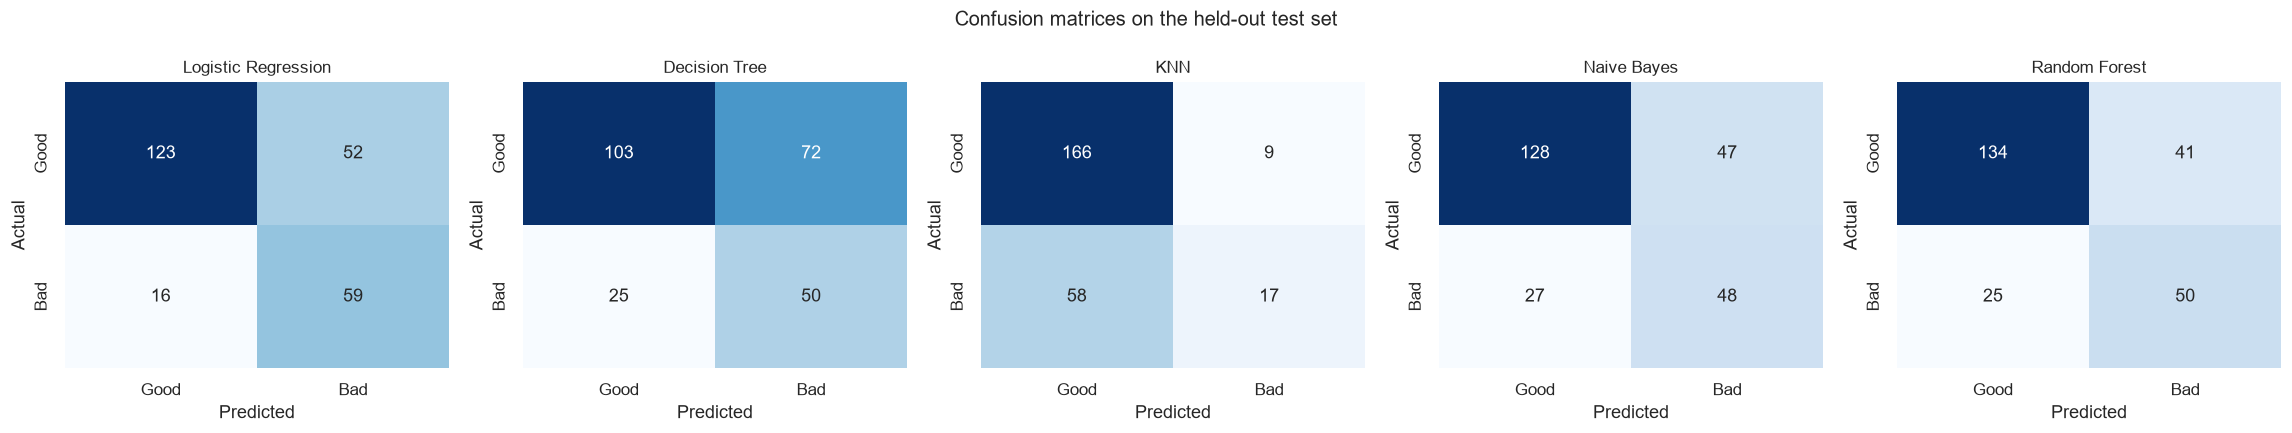

In [16]:
"""Confusion matrices for all five classifiers."""

fig, axes = plt.subplots(1, 5, figsize=(21, 4))
for axis, (name, model) in zip(axes, fitted_models.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Good", "Bad"],
        yticklabels=["Good", "Bad"],
        ax=axis,
    )
    axis.set_title(name, fontsize=11)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
fig.suptitle("Confusion matrices on the held-out test set", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

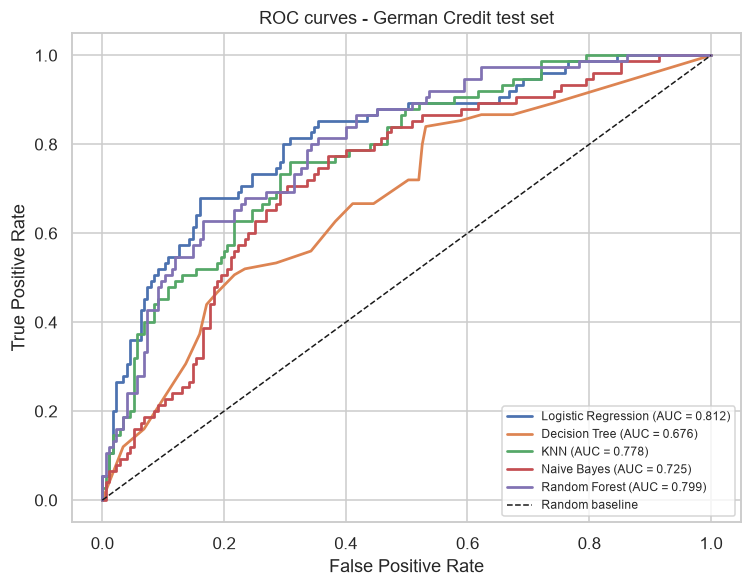

In [17]:
"""ROC curves - discriminative power independent of the 0.5 decision threshold."""

fig, axis = plt.subplots(figsize=(7, 5.5))
for name, model in fitted_models.items():
    scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    axis.plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC = {roc_auc_score(y_test, scores):.3f})")
axis.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("ROC curves - German Credit test set")
axis.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()

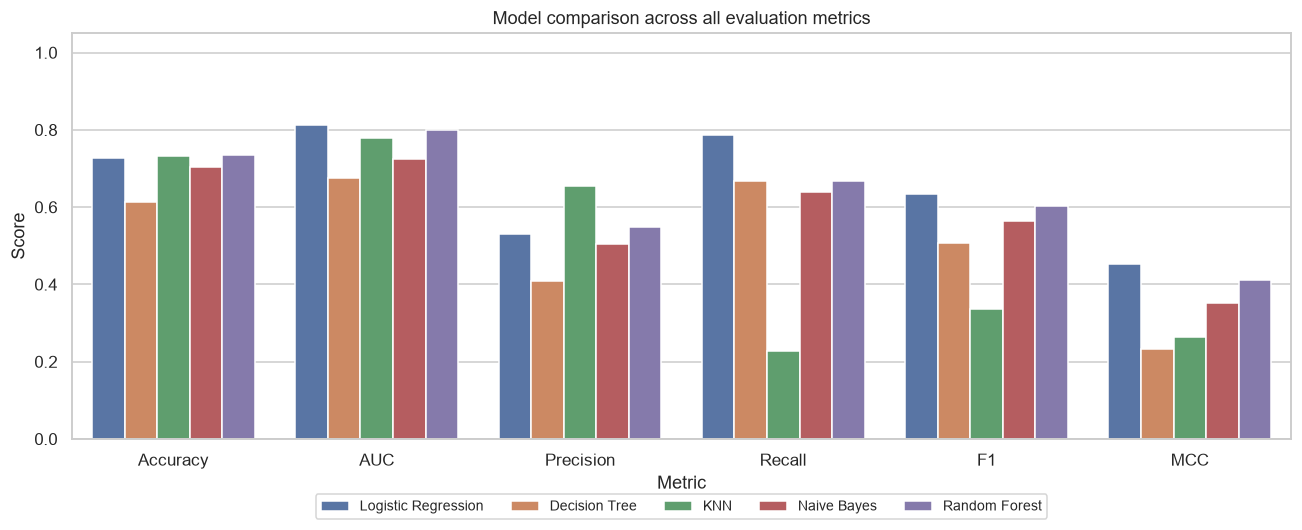

In [18]:
"""Grouped bar chart of all six metrics for a visual side-by-side comparison."""

melted = results.melt(id_vars="ML Model", var_name="Metric", value_name="Score")
fig, axis = plt.subplots(figsize=(12, 5))
sns.barplot(data=melted, x="Metric", y="Score", hue="ML Model", ax=axis)
axis.set_ylim(0, 1.05)
axis.set_title("Model comparison across all evaluation metrics")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "metric_comparison.png", bbox_inches="tight")
plt.show()

In [19]:
"""Detailed classification report of the overall winner."""

winner = fitted_models[best_model_name]
print(f"Classification report - {best_model_name}\n")
print(
    classification_report(
        y_test,
        winner.predict(X_test),
        target_names=["Good risk", "Bad risk"],
        digits=4,
    )
)

Classification report - Logistic Regression

              precision    recall  f1-score   support

   Good risk     0.8849    0.7029    0.7834       175
    Bad risk     0.5315    0.7867    0.6344        75

    accuracy                         0.7280       250
   macro avg     0.7082    0.7448    0.7089       250
weighted avg     0.7789    0.7280    0.7387       250



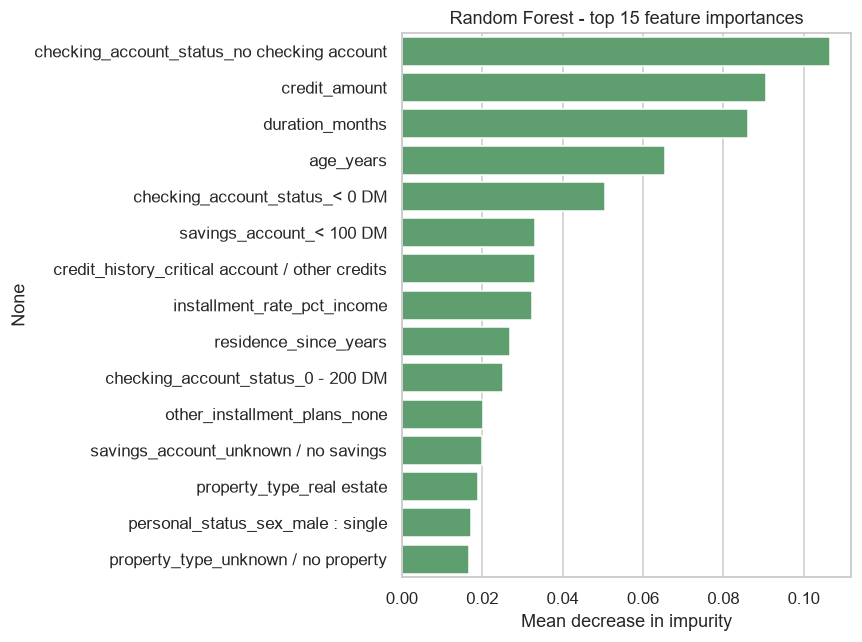

checking_account_status_no checking account        0.1065
credit_amount                                      0.0907
duration_months                                    0.0862
age_years                                          0.0654
checking_account_status_< 0 DM                     0.0506
savings_account_< 100 DM                           0.0333
credit_history_critical account / other credits    0.0331
installment_rate_pct_income                        0.0324
residence_since_years                              0.0269
checking_account_status_0 - 200 DM                 0.0252
other_installment_plans_none                       0.0202
savings_account_unknown / no savings               0.0200
property_type_real estate                          0.0191
personal_status_sex_male : single                  0.0171
property_type_unknown / no property                0.0167
dtype: float64

In [20]:
"""Top drivers of credit risk learned by the Random Forest."""

rf_pipeline = fitted_models["Random Forest"]
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, axis = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, ax=axis, color="#55a868")
axis.set_title("Random Forest - top 15 feature importances")
axis.set_xlabel("Mean decrease in impurity")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()

importances.head(15).round(4)

## 7. Model persistence

Each fitted pipeline is serialised with `joblib` into `models/*.pkl`. A companion
`models/metadata.json` records the schema, the positive class and the file mapping so
that `app.py` never has to hard-code column names.

In [21]:
"""Serialise the pipelines and write the deployment metadata."""

saved_files = {}
for name, spec in MODEL_SPECS.items():
    destination = MODEL_DIR / f"{spec['slug']}.pkl"
    joblib.dump(fitted_models[name], destination)
    saved_files[name] = destination.name
    print(f"Saved {name:<22} -> models/{destination.name} "
          f"({destination.stat().st_size / 1024:.1f} KB)")

metadata = {
    "project": "German Credit Risk Classification",
    "dataset": "UCI Statlog (German Credit Data)",
    "dataset_url": "https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data",
    "created_on": date.today().isoformat(),
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "target_column": TARGET,
    "positive_label": POSITIVE_LABEL,
    "negative_label": "Good",
    "class_names": ["Good", "Bad"],
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_order": X.columns.tolist(),
    "models": saved_files,
    "n_train_rows": int(X_train.shape[0]),
    "n_test_rows": int(X_test.shape[0]),
}
with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2)

print("\nSaved -> models/metadata.json")

Saved Logistic Regression    -> models/logistic_regression.pkl (8.9 KB)
Saved Decision Tree          -> models/decision_tree.pkl (13.0 KB)
Saved KNN                    -> models/knn.pkl (371.6 KB)
Saved Naive Bayes            -> models/naive_bayes.pkl (10.2 KB)
Saved Random Forest          -> models/random_forest.pkl (8751.5 KB)

Saved -> models/metadata.json


In [22]:
"""Reload one artefact to prove the saved pipelines are deployment ready."""

reloaded = joblib.load(MODEL_DIR / f"{MODEL_SPECS[best_model_name]['slug']}.pkl")
sample = pd.read_csv(ROOT / "test_data.csv").drop(columns=TARGET).head(5)
print("Round-trip predictions on 5 raw rows:", reloaded.predict(sample))
print("Round-trip probabilities (Bad):", reloaded.predict_proba(sample)[:, 1].round(3))

Round-trip predictions on 5 raw rows: [1 0 0 0 1]
Round-trip probabilities (Bad): [0.875 0.185 0.16  0.156 0.504]


## 8. Summary

The final comparison table is stored in `reports/evaluation_results.csv`, the figures
in `reports/figures/`, and the five deployable pipelines in `models/`. The written
model-by-model observations and the declaration of the overall winner are documented
in `README.md`, which also forms part of the submitted PDF report.